In [18]:
# Importing data and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path="/Users/gauravkhanal/Desktop/Coding_files/data_analysis/healthcare_dataset.csv"
data=pd.read_csv(path)

#Commands used to study data

#data.head(5) => samples
#data.shape => to check the values
#data.info => to check for null values and data types 
#data['Test Results'].unique() => to check the unique values of each columns

In [19]:
#Data Cleanup and presentation
shade_1='#0889BC'
shade_2='#FF3D61'
shade_3='#A5B202'
shade_4='#01B6A9'
shade_5='#EC9076'
shade_6='#DB76DC'
shade_7='#01BD55'

def name_cleanup(x):
    split=str(x).strip().split(" ")
    final_name = [name.lower().capitalize() for name in split]
    return " ".join(final_name)

def roundoff(x):
    return round(x,2)

def trailing_comma(x):
    return x.rstrip(",")

age_group_coditions = [ data['Age'].between(13,19), data['Age'].between(20,23), data['Age'].between(24,59)]
age_groups =['Teen','Young Adult','Adult']

data['Age Group'] = np.select(age_group_coditions,age_groups,default='Senior') #Creating a new columns "Age Groups"
data['Name'] = data['Name'].apply(name_cleanup) #fixing cases in the name
data['Billing Amount'] = data['Billing Amount'].apply(roundoff) #round off to 2 decimal places #55497 & 8
data['Hospital']= data['Hospital'].apply(trailing_comma) #removing the trailing commas in some hospital names
data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal,Adult
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Senior
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal,Senior
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal,Adult
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.71,417,Elective,2020-09-15,Penicillin,Abnormal,Adult
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.80,316,Elective,2020-02-01,Aspirin,Normal,Senior
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,and Mahoney Johnson Vasquez,UnitedHealthcare,27620.76,347,Urgent,2020-08-10,Ibuprofen,Abnormal,Adult
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,Jackson Todd and Castro,Medicare,32451.09,321,Elective,2019-05-31,Ibuprofen,Abnormal,Adult


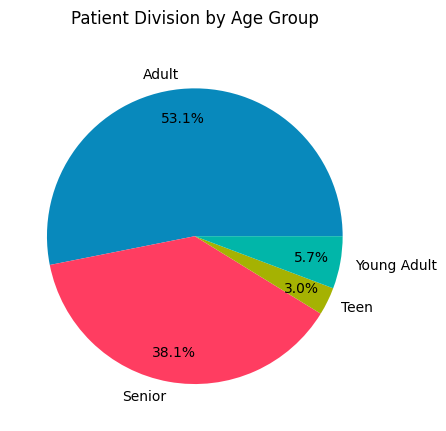

In [20]:
#Pie chart division by age groups
ag=data[['Name','Age Group']].groupby(by='Age Group').count().reset_index().rename(columns={"Name":"Count"})
agedivison_color= [shade_1,shade_2,shade_3,shade_4]
ag['Percent']=round(ag['Count'] / int(ag['Count'].sum()) * 100,2)
plt.pie(ag['Percent'],labels=ag['Age Group'],colors=agedivison_color,autopct='%1.1f%%',labeldistance=1.1,pctdistance=0.8)
plt.title('Patient Division by Age Group',loc='center',pad=20)
plt.show()

Text(0.5, 1.0, 'Patient count by Diseases')

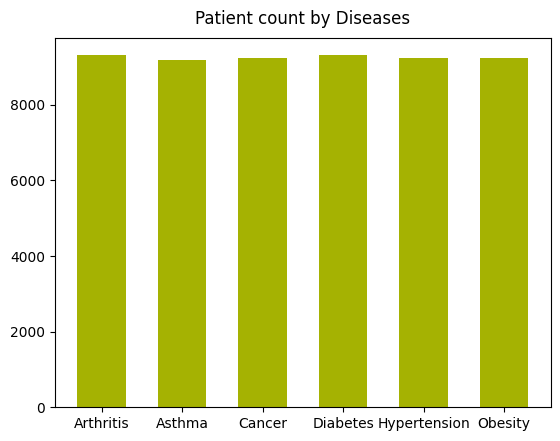

In [21]:
#Medical Condition Bar Chart
mc_table=data[['Name','Medical Condition']].groupby(by='Medical Condition').count().reset_index().rename(columns={"Name":"Count"})
plt.bar(mc_table['Medical Condition'],mc_table['Count'],width=.6,color=shade_3)
plt.title('Patient count by Diseases',pad=10)

Text(0.5, 1.0, 'Admission Count by Quarter')

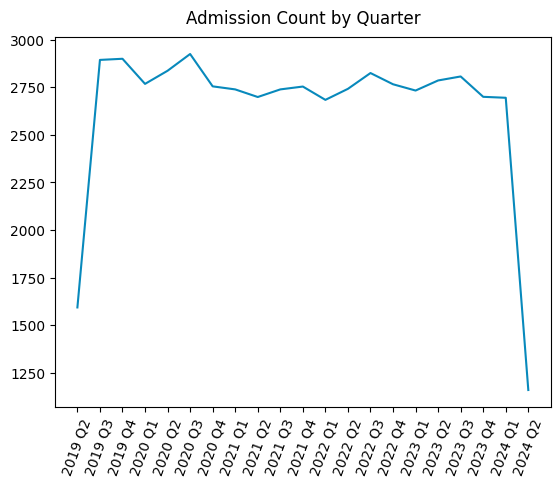

In [22]:
#min = 2019-05-08
#max = 2024-05-07
#q1 = 01 to 03 | q2 = 04 to 06 | q3 = 07 to 09 | q4 = 10 to 12
# Admission quarter

admission_conditions =[
    data['Date of Admission'].between("2019-04-01","2019-06-31"),
    data['Date of Admission'].between("2019-07-01","2019-09-31"),
    data['Date of Admission'].between("2019-10-01","2019-12-31"),
    data['Date of Admission'].between("2020-01-01","2020-03-31"),
    data['Date of Admission'].between("2020-04-01","2020-06-31"),
    data['Date of Admission'].between("2020-07-01","2020-09-31"),
    data['Date of Admission'].between("2020-10-01","2020-12-31"),
    data['Date of Admission'].between("2021-01-01","2021-03-31"),
    data['Date of Admission'].between("2021-04-01","2021-06-31"),
    data['Date of Admission'].between("2021-07-01","2021-09-31"),
    data['Date of Admission'].between("2021-10-01","2021-12-31"),
    data['Date of Admission'].between("2022-01-01","2022-03-31"),
    data['Date of Admission'].between("2022-04-01","2022-06-31"),
    data['Date of Admission'].between("2022-07-01","2022-09-31"),
    data['Date of Admission'].between("2022-10-01","2022-12-31"),
    data['Date of Admission'].between("2023-01-01","2023-03-31"),
    data['Date of Admission'].between("2023-04-01","2023-06-31"),
    data['Date of Admission'].between("2023-07-01","2023-09-31"),
    data['Date of Admission'].between("2023-10-01","2023-12-31"),
    data['Date of Admission'].between("2024-01-01","2024-03-31"),
    data['Date of Admission'].between("2024-04-01","2024-06-31") ]
admission_quarter_labels=["2019 Q2","2019 Q3","2019 Q4",
                          "2020 Q1","2020 Q2","2020 Q3","2020 Q4",
                          "2021 Q1","2021 Q2","2021 Q3","2021 Q4",
                          "2022 Q1","2022 Q2","2022 Q3","2022 Q4",
                          "2023 Q1","2023 Q2","2023 Q3","2023 Q4",
                          "2024 Q1","2024 Q2"]

data['Admission Quarter'] = np.select(admission_conditions,admission_quarter_labels,default = "After 2024 Q2")
admission_table=data[['Admission Quarter','Name']].groupby(by='Admission Quarter').count().reset_index().rename(columns={"Name":"Count"}).sort_values(by='Admission Quarter')

plt.plot(admission_table['Admission Quarter'],admission_table['Count'],color=shade_1)
plt.xticks(rotation=70)
plt.title('Admission Count by Quarter',pad=10)